# Carga y comprensión del dataset

Para no subir el archivo a collab ya que es grande y va lento lo cargamos desde drive luego lo llamamos, obtenemos una muestra y mostramos la información básica para ver que todo está bien

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

path = "/content/drive/MyDrive/TFG/final_dataset.csv"

df = pd.read_csv(path)

df.head()

,user_id,work_id,rating,date,title,subjects_str
0,0,OL17882343W,3,2018-06-20,Magick & Mayhem,fiction mystery magic witches cozy cats Merlin...
1,1,OL1629179W,5,2018-06-20,Kasaysayan ng bayang Pilipino,History
2,3,OL5264255W,5,2018-06-20,Linear and nonlinear circuits,Linear Electric circuits Nonlinear Electric ci...
3,4,OL1681415W,5,2018-06-20,Pushing up people,Success in business
4,5,OL1837390W,5,2018-06-20,Natives of eternity,Angels Christward Ministry


In [3]:
print(df.shape)
print(df.columns)
df.info()

(491004, 6)
Index(['user_id', 'work_id', 'rating', 'date', 'title', 'subjects_str'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491004 entries, 0 to 491003
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       491004 non-null  int64 
 1   work_id       491004 non-null  object
 2   rating        491004 non-null  int64 
 3   date          491004 non-null  object
 4   title         491004 non-null  object
 5   subjects_str  491004 non-null  object
dtypes: int64(2), object(4)
memory usage: 22.5+ MB


# Análisis descriptivo de las variables

Vamos a hacer un pequeño análisis de las distintas variables para ver que insights podemos obtener de esto, recordando que hay variables de distintos tipos tanto categóricas como numéricas

In [4]:
import pandas as pd

# 1 estadisticas generales.
print("Estadísticas generales del rating:")
print(df["rating"].describe())

# 2 distribucion de ratings.
print("\nFrecuencia de ratings:")
print(df["rating"].value_counts().sort_index())

# 3 numero de libros unicos.
print("\nNúmero de libros únicos:")
print(df["work_id"].nunique())

# 4 ratings por libro.
ratings_per_book = df.groupby("work_id")["rating"].count()

print("\nMedia de ratings por libro:")
print(ratings_per_book.mean())

print("\nMáximo de ratings en un libro:")
print(ratings_per_book.max())

print("\nMínimo de ratings en un libro:")
print(ratings_per_book.min())

# 5 libros mas valorados.
top_books = df.groupby("title")["rating"].count().sort_values(ascending=False).head(10)

print("\nTop 10 libros con más valoraciones:")
print(top_books)

# 6 longitud del contenido.
df["subjects_length"] = df["subjects_str"].apply(lambda x: len(str(x).split()))

print("\nLongitud media de subjects:")
print(df["subjects_length"].mean())

print("\nLongitud máxima de subjects:")
print(df["subjects_length"].max())

# 7 variable temporal.
df["date"] = pd.to_datetime(df["date"])

print("\nRango de fechas:")
print(df["date"].min(), "-", df["date"].max())

print("\nNúmero de años distintos:")
print(df["date"].dt.year.nunique())

Estadísticas generales del rating:
count    491004.000000
mean          3.990336
std           1.136063
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64

Frecuencia de ratings:
rating
1     24560
2     28024
3     87817
4    137803
5    212800
Name: count, dtype: int64

Número de libros únicos:
207640

Media de ratings por libro:
2.3646888846079754

Máximo de ratings en un libro:
1235

Mínimo de ratings en un libro:
1

Top 10 libros con más valoraciones:
title
Atomic Habits                                 1235
Um casamento arranjado                        1139
The 48 Laws of Power                          1079
Rich Dad, Poor Dad                            1049
It Ends With Us                               1037
Harry Potter and the Philosopher's Stone       934
A Game of Thrones                              721
The Subtle Art of Not Giving a F*ck            687
Harry Potter and the Prisoner of

# **Análisis del dato**

# Análisis de la distribución de ratings

En este apartado vamos a hacer un análisis más detallado de la variable rating. En particular, se estudia la frecuencia de cada puntuación y la forma en la que se distribuyen los datos, lo que permitirá identificar posibles sesgos y evaluar su impacto en el sistema de recomendación

Frecuencia de ratings:
rating
1     24560
2     28024
3     87817
4    137803
5    212800
Name: count, dtype: int64


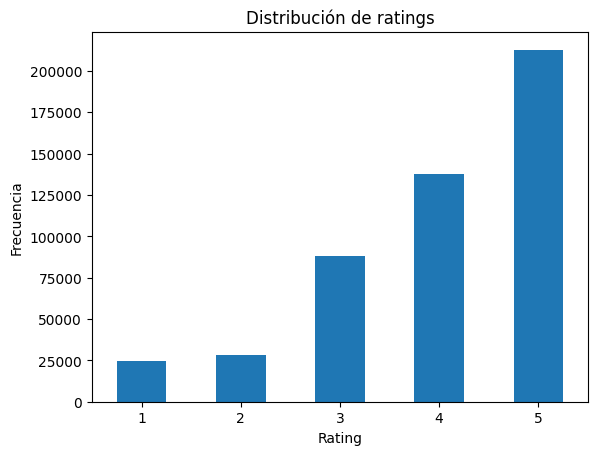

Proporción de ratings = 5: 0.433397691261171
Proporción de ratings >= 4: 0.7140532460020692
Proporción de ratings <= 2: 0.10709485055111567


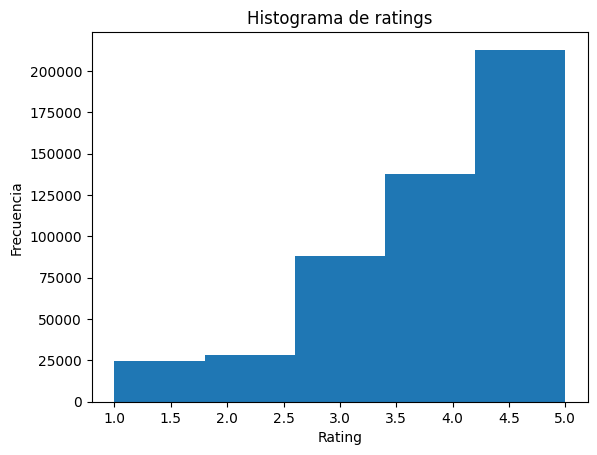

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# distribucion de ratings.
rating_counts = df["rating"].value_counts().sort_index()

print("Frecuencia de ratings:")
print(rating_counts)

# grafico de barras
plt.figure()
rating_counts.plot(kind="bar")
plt.title("Distribución de ratings")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

# proporcion de ratings.
total = len(df)

prop_5 = (df["rating"] == 5).sum() / total
prop_4_5 = (df["rating"] >= 4).sum() / total
prop_low = (df["rating"] <= 2).sum() / total

print("Proporción de ratings = 5:", prop_5)
print("Proporción de ratings >= 4:", prop_4_5)
print("Proporción de ratings <= 2:", prop_low)

# histograma de ratings.
plt.figure()
plt.hist(df["rating"], bins=5)
plt.title("Histograma de ratings")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.show()

# Análisis de popularidad

Se calcula el número de valoraciones por libro para analizar su popularidad, obteniendo estadísticas como media, mínimo y máximo.
Además, se visualiza la distribución de esta popularidad y se identifican los libros con mayor número de valoraciones.

Media de ratings por libro:
2.3646888846079754

Máximo de ratings en un libro:
1235

Mínimo de ratings en un libro:
1


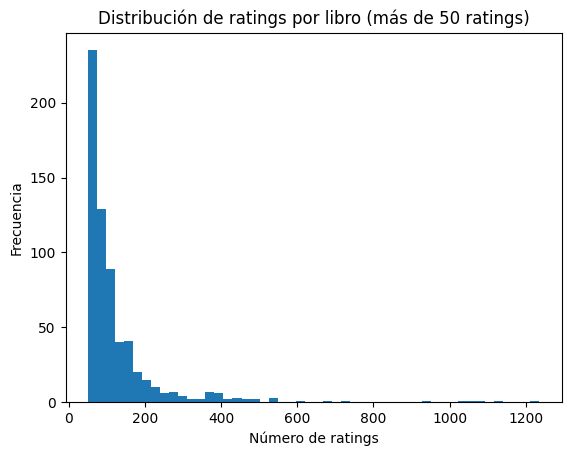

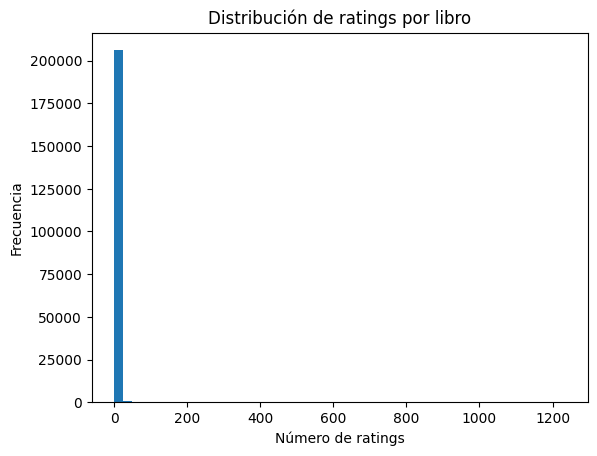


Top 10 libros más valorados:
title
Atomic Habits                                 1235
Um casamento arranjado                        1139
The 48 Laws of Power                          1079
Rich Dad, Poor Dad                            1049
It Ends With Us                               1037
Harry Potter and the Philosopher's Stone       934
A Game of Thrones                              721
The Subtle Art of Not Giving a F*ck            687
Harry Potter and the Prisoner of Azkaban       603
Control Your Mind and Master Your Feelings     538
Name: rating, dtype: int64


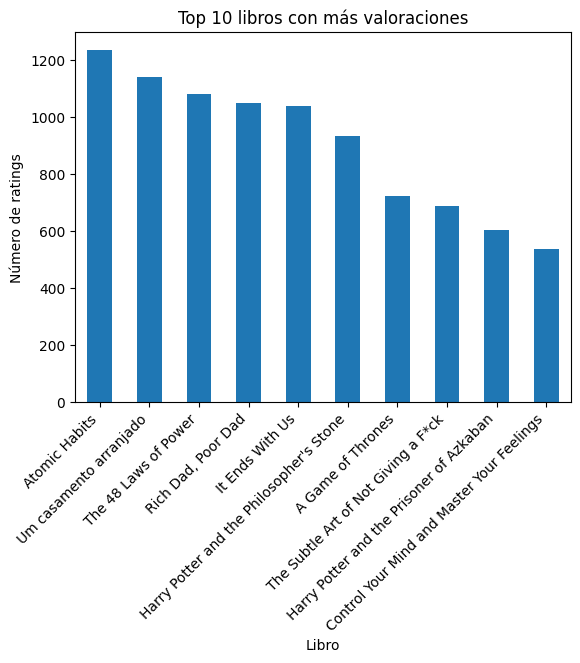

In [6]:
# 1 ratings por libro.
ratings_per_book = df.groupby("work_id")["rating"].count()

print("Media de ratings por libro:")
print(ratings_per_book.mean())

print("\nMáximo de ratings en un libro:")
print(ratings_per_book.max())

print("\nMínimo de ratings en un libro:")
print(ratings_per_book.min())

# distribucion filtrada (quitando libros con pocas valoraciones).
filtered = ratings_per_book[ratings_per_book > 50]

plt.figure()
plt.hist(filtered, bins=50)
plt.title("Distribución de ratings por libro (más de 50 ratings)")
plt.xlabel("Número de ratings")
plt.ylabel("Frecuencia")
plt.show()

# 2 distribucion de popularidad.
plt.figure()
plt.hist(ratings_per_book, bins=50)
plt.title("Distribución de ratings por libro")
plt.xlabel("Número de ratings")
plt.ylabel("Frecuencia")
plt.show()

# 3 top libros mas valorados.
top_books = df.groupby("title")["rating"].count().sort_values(ascending=False).head(10)

print("\nTop 10 libros más valorados:")
print(top_books)

# grafico top libros
plt.figure()
top_books.plot(kind="bar")
plt.title("Top 10 libros con más valoraciones")
plt.xlabel("Libro")
plt.ylabel("Número de ratings")
plt.xticks(rotation=45, ha="right")
plt.show()

# Análisis del contenido

En este apartado se analiza la variable subjects_str, que contiene la información descriptiva de cada obra, con el objetivo de evaluar la riqueza y utilidad de estos datos para el modelo basado en contenido. En particular, se estudia la longitud de las descripciones y la frecuencia de las palabras más utilizadas,para ver el potencial para establecer similitudes entre libros.

Longitud media:
36.18415939585014

Longitud maxima:
1305

Longitud minima:
1


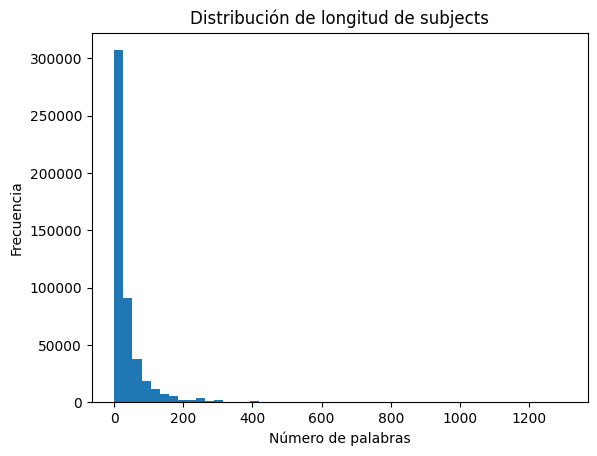


Top 10 palabras más frecuentes:
fiction : 1009649
and : 384679
Fiction, : 382378
Fiction : 353790
& : 221803
general : 182174
Children's : 139996
Juvenile : 139828
/ : 131482
literature : 127384


In [7]:
# 1 longitud del contenido.
df["subjects_length"] = df["subjects_str"].apply(lambda x: len(str(x).split()))

print("Longitud media:")
print(df["subjects_length"].mean())

print("\nLongitud maxima:")
print(df["subjects_length"].max())

print("\nLongitud minima:")
print(df["subjects_length"].min())

# 2 distribucion longitud.
plt.figure()
plt.hist(df["subjects_length"], bins=50)
plt.title("Distribución de longitud de subjects")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

# 3 palabras mas frecuentes.
from collections import Counter

all_words = " ".join(df["subjects_str"].dropna()).split()
word_counts = Counter(all_words)

top_words = word_counts.most_common(10)

print("\nTop 10 palabras más frecuentes:")
for word, count in top_words:
    print(word, ":", count)

# Modelo CBF

In [8]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
# eliminamos títulos duplicados porque si no va a recomendar el mismo libro en otra variante
df_model = df[["work_id", "title", "subjects_str"]].dropna()

df_model = df_model.drop_duplicates(subset="work_id")

df_model = df_model.reset_index(drop=True)

print("Número de libros:", len(df_model))

Número de libros: 207640


In [10]:
# como el vector tf-idf filtra por mayusc y minusc estadarizamos y quitamos símbolos molestos
import re

df_model["subjects_str"] = df_model["subjects_str"].str.lower()

df_model["subjects_str"] = df_model["subjects_str"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", " ", str(x))
)

In [11]:
# aplicamos el vector tf-idf, primero eliminamos las stop words para que nos recomiende por categoría y no se metan en la recomendacion
vectorizer = TfidfVectorizer(stop_words="english")

# luego esta función lo que hace es asignar a cada palabra un valor numérico es decir a history le da el 0.1 a fiction el 0.2 etc para poder recomendar
tfidf_matrix = vectorizer.fit_transform(df_model["subjects_str"])

print("Dimensiones de la matriz:", tfidf_matrix.shape)

Dimensiones de la matriz: (207640, 61873)


In [12]:
# creamos un índice de filas para poder buscar un libro concreto y que nos recomiende
indices = pd.Series(df_model.index, index=df_model["title"])

print(indices.head())

title
Magick & Mayhem                  0
Kasaysayan ng bayang Pilipino    1
Linear and nonlinear circuits    2
Pushing up people                3
Natives of eternity              4
dtype: int64


In [13]:
# funcion de recomendacion en base a cbf
def recommend(title, n=5):

    matches = df_model[df_model["title"] == title]

    if matches.empty:
        return "Libro no encontrado"

    idx = matches.index[0]

    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    sim_indices = sim_scores.argsort()[::-1][1:n+1]

    print("Libro pedido:")
    print(df_model.iloc[idx]["title"])
    print("Subjects:", df_model.iloc[idx]["subjects_str"])
    print("\nRecomendaciones:\n")

    for i, sim_idx in enumerate(sim_indices):
        print(f"Top {i+1}:")
        print(df_model.iloc[sim_idx]["title"])
        print("Subjects:", df_model.iloc[sim_idx]["subjects_str"])
        print("-" * 50)

In [14]:
# prueba
recommend("Atomic Habits")

Libro pedido:
Atomic Habits
Subjects: habit habit breaking behavior modification self actualization  psychology  business psychology personal growth new york times bestseller business   economics   organizational behavior psychology   social psychology self help   personal growth   general 

Recomendaciones:

Top 1:
The culture code
Subjects: corporate culture leadership self help   personal growth   general teams in the workplace business   economics   organizational behavior psychology   social psychology nyt business books            new york times bestseller business   economics organizational behavior psychology social psychology self help personal growth general
--------------------------------------------------
Top 2:
Better Than Before
Subjects: habit change  psychology  self help   personal growth   general self help   personal growth   success self help   personal growth   happiness nyt advice how to and miscellaneous            new york times bestseller new york times review

# Evaluacion del modelo

Numero de recomendaciones analizadas: 5000
Similitud media: 0.705473737094535
Similitud mediana: 0.7052761071961151
Similitud maxima: 1.0000000000000004
Similitud minima: 0.0
Desviacion tipica: 0.19356279568338855


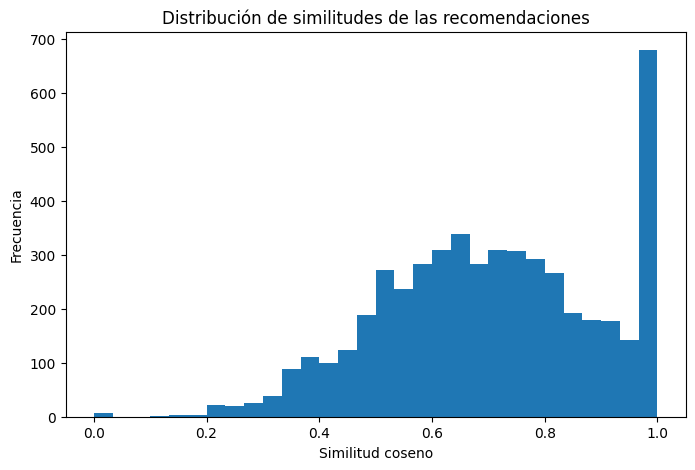

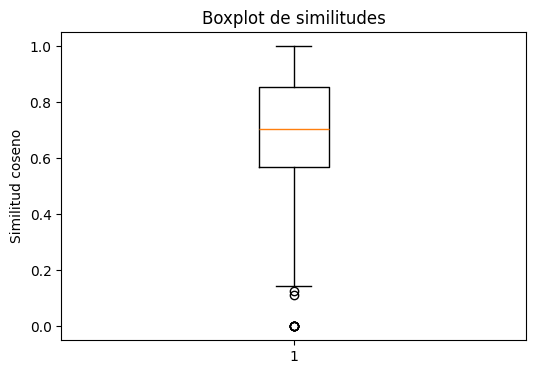

In [18]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt

# muestra aleatoria de 500 libros
sample_books = df_model.sample(500, random_state=42)

all_similarities = []

for idx in sample_books.index:

    sims = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()

    sims[idx] = 0

    top_scores = np.sort(sims)[-10:]

    all_similarities.extend(top_scores)

print("Numero de recomendaciones analizadas:", len(all_similarities))
print("Similitud media:", np.mean(all_similarities))
print("Similitud mediana:", np.median(all_similarities))
print("Similitud maxima:", np.max(all_similarities))
print("Similitud minima:", np.min(all_similarities))
print("Desviacion tipica:", np.std(all_similarities))

# histograma
plt.figure(figsize=(8,5))
plt.hist(all_similarities, bins=30)
plt.title("Distribución de similitudes de las recomendaciones")
plt.xlabel("Similitud coseno")
plt.ylabel("Frecuencia")
plt.show()

# boxplot
plt.figure(figsize=(6,4))
plt.boxplot(all_similarities)
plt.title("Boxplot de similitudes")
plt.ylabel("Similitud coseno")
plt.show()

# Descargas Power BI

In [24]:
import pandas as pd

similaridades_df = pd.DataFrame({
    "similaridad": all_similarities
})

# redondear a 4 decimales
similaridades_df["similaridad"] = (
    similaridades_df["similaridad"]
    .round(4)
)

# guardar csv
similaridades_df.to_csv(
    "similaridades.csv",
    index=False
)

print(similaridades_df.head())

   similaridad
0       0.5119
1       0.5119
2       0.5119
3       0.5119
4       0.5119


In [25]:
from google.colab import files

files.download("similaridades.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
df_model["subjects_length"] = (
    df_model["subjects_str"]
    .str.split()
    .apply(len)
)

df_model[["subjects_length"]].to_csv(
    "subjects_length.csv",
    index=False
)

files.download("subjects_length.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>